# 02 — Per-Product Microstructure (Order Book Family)

**Assignment**: Explorer 02, R5 EDA Swarm  
**Lenses**: Spread regime, book imbalance, depth asymmetry, missing levels, queue stickiness  
**Data**: `prices_round_5_day_{2,3,4}.csv` (semicolon-separated, read-only)  
**Products**: 50 products, 10 categories × 5  

All claims are backed by computed numbers. No strategy proposals, no PnL claims.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

BASE = '/Users/bensinek/Documents/Coding/Prosperity4/data/round_5/prices'

# Load all three days
frames = []
for day in [2, 3, 4]:
    path = f'{BASE}/prices_round_5_day_{day}.csv'
    d = pd.read_csv(path, sep=';')
    frames.append(d)

df_all = pd.concat(frames, ignore_index=True)
print(f'Total rows: {len(df_all):,}')
print(f'Days: {sorted(df_all["day"].unique())}')
print(f'Products: {sorted(df_all["product"].unique())}')
print(f'Columns: {df_all.columns.tolist()}')

PRODUCTS = sorted(df_all['product'].unique())
CATEGORIES = {
    'GALAXY_SOUNDS': [p for p in PRODUCTS if p.startswith('GALAXY_SOUNDS')],
    'SLEEP_POD':     [p for p in PRODUCTS if p.startswith('SLEEP_POD')],
    'MICROCHIP':     [p for p in PRODUCTS if p.startswith('MICROCHIP')],
    'PEBBLES':       [p for p in PRODUCTS if p.startswith('PEBBLES')],
    'ROBOT':         [p for p in PRODUCTS if p.startswith('ROBOT')],
    'UV_VISOR':      [p for p in PRODUCTS if p.startswith('UV_VISOR')],
    'TRANSLATOR':    [p for p in PRODUCTS if p.startswith('TRANSLATOR')],
    'PANEL':         [p for p in PRODUCTS if p.startswith('PANEL')],
    'OXYGEN_SHAKE':  [p for p in PRODUCTS if p.startswith('OXYGEN_SHAKE')],
    'SNACKPACK':     [p for p in PRODUCTS if p.startswith('SNACKPACK')],
}
print('\nCategory sizes:')
for cat, prods in CATEGORIES.items():
    print(f'  {cat}: {len(prods)} products')

Total rows: 1,500,000
Days: [np.int64(2), np.int64(3), np.int64(4)]
Products: ['GALAXY_SOUNDS_BLACK_HOLES', 'GALAXY_SOUNDS_DARK_MATTER', 'GALAXY_SOUNDS_PLANETARY_RINGS', 'GALAXY_SOUNDS_SOLAR_FLAMES', 'GALAXY_SOUNDS_SOLAR_WINDS', 'MICROCHIP_CIRCLE', 'MICROCHIP_OVAL', 'MICROCHIP_RECTANGLE', 'MICROCHIP_SQUARE', 'MICROCHIP_TRIANGLE', 'OXYGEN_SHAKE_CHOCOLATE', 'OXYGEN_SHAKE_EVENING_BREATH', 'OXYGEN_SHAKE_GARLIC', 'OXYGEN_SHAKE_MINT', 'OXYGEN_SHAKE_MORNING_BREATH', 'PANEL_1X2', 'PANEL_1X4', 'PANEL_2X2', 'PANEL_2X4', 'PANEL_4X4', 'PEBBLES_L', 'PEBBLES_M', 'PEBBLES_S', 'PEBBLES_XL', 'PEBBLES_XS', 'ROBOT_DISHES', 'ROBOT_IRONING', 'ROBOT_LAUNDRY', 'ROBOT_MOPPING', 'ROBOT_VACUUMING', 'SLEEP_POD_COTTON', 'SLEEP_POD_LAMB_WOOL', 'SLEEP_POD_NYLON', 'SLEEP_POD_POLYESTER', 'SLEEP_POD_SUEDE', 'SNACKPACK_CHOCOLATE', 'SNACKPACK_PISTACHIO', 'SNACKPACK_RASPBERRY', 'SNACKPACK_STRAWBERRY', 'SNACKPACK_VANILLA', 'TRANSLATOR_ASTRO_BLACK', 'TRANSLATOR_ECLIPSE_CHARCOAL', 'TRANSLATOR_GRAPHITE_MIST', 'TRANSLATOR_SPA

## Cell 2 — Derived microstructure columns

Compute per-tick metrics we will aggregate:  
- `spread`: ask_price_1 - bid_price_1  
- `mid`: (ask_price_1 + bid_price_1) / 2  
- `imbalance_l1`: (bid_vol_1 - ask_vol_1) / (bid_vol_1 + ask_vol_1)  
- `imbalance_l2`: same at level 2 where available  
- `depth_bid_l1`, `depth_ask_l1`: individual side volumes at L1  
- `has_l2`, `has_l3`: presence of levels 2 and 3  
- `depth_asymmetry`: (bid_vol_l1 - ask_vol_l1) / (bid_vol_l1 + ask_vol_l1) same as imbalance_l1; rename for clarity  
- `total_bid_depth`, `total_ask_depth`: sum of all bid/ask volumes available

In [2]:
df = df_all.copy()

# Spread
df['spread'] = df['ask_price_1'] - df['bid_price_1']

# Mid price
df['mid'] = (df['ask_price_1'] + df['bid_price_1']) / 2

# Level presence flags
df['has_l2_bid'] = df['bid_price_2'].notna().astype(int)
df['has_l2_ask'] = df['ask_price_2'].notna().astype(int)
df['has_l3_bid'] = df['bid_price_3'].notna().astype(int)
df['has_l3_ask'] = df['ask_price_3'].notna().astype(int)

# Book imbalance at L1
denom_l1 = df['bid_volume_1'] + df['ask_volume_1']
df['imbalance_l1'] = (df['bid_volume_1'] - df['ask_volume_1']) / denom_l1

# Book imbalance at L2 (only where both sides present)
mask_l2 = df['bid_volume_2'].notna() & df['ask_volume_2'].notna()
df.loc[mask_l2, 'imbalance_l2'] = (
    (df.loc[mask_l2, 'bid_volume_2'] - df.loc[mask_l2, 'ask_volume_2']) /
    (df.loc[mask_l2, 'bid_volume_2'] + df.loc[mask_l2, 'ask_volume_2'])
)

# Total depth per side (L1+L2+L3 where available)
df['total_bid_depth'] = df['bid_volume_1'].fillna(0) + df['bid_volume_2'].fillna(0) + df['bid_volume_3'].fillna(0)
df['total_ask_depth'] = df['ask_volume_1'].fillna(0) + df['ask_volume_2'].fillna(0) + df['ask_volume_3'].fillna(0)

# Depth asymmetry across all levels
total_denom = df['total_bid_depth'] + df['total_ask_depth']
df['depth_asymmetry_total'] = (df['total_bid_depth'] - df['total_ask_depth']) / total_denom

# L1 bid-ask tick gap (number of ticks between best bid and best ask)
# (same as spread but useful to see as integer)
df['spread_ticks'] = (df['ask_price_1'] - df['bid_price_1']).astype(int)

print('Derived columns added:', ['spread','mid','has_l2_bid','has_l2_ask','has_l3_bid','has_l3_ask',
                                   'imbalance_l1','imbalance_l2','total_bid_depth','total_ask_depth',
                                   'depth_asymmetry_total','spread_ticks'])
print(f'Total rows with derived columns: {len(df):,}')

Derived columns added: ['spread', 'mid', 'has_l2_bid', 'has_l2_ask', 'has_l3_bid', 'has_l3_ask', 'imbalance_l1', 'imbalance_l2', 'total_bid_depth', 'total_ask_depth', 'depth_asymmetry_total', 'spread_ticks']
Total rows with derived columns: 1,500,000


## Cell 3 — Spread regime: per-product statistics across days 2/3/4

For each product, compute mean, median, std, and mode of the spread. Products with a very tight or very consistent spread may have more predictable mid-price dynamics.

In [3]:
# Spread statistics per product per day
spread_by_day = df.groupby(['product','day'])['spread'].agg(['mean','median','std','min','max']).round(3)

# Cross-day spread stats (all 3 days combined)
spread_overall = df.groupby('product')['spread'].agg(['mean','median','std','min','max']).round(3)
spread_overall.columns = ['mean','median','std','min','max']
spread_overall = spread_overall.sort_values('mean')

# Mode spread per product
spread_mode = df.groupby('product')['spread'].agg(lambda x: x.mode()[0])
spread_overall['mode'] = spread_mode

# CV (coefficient of variation) = std/mean
spread_overall['cv'] = (spread_overall['std'] / spread_overall['mean']).round(4)

print('=== Spread stats (all 3 days) — sorted by mean spread ===')
print(spread_overall.to_string())

# Identify tightest and widest
print(f'\nTightest 5 mean spreads: {spread_overall.head(5).index.tolist()}')
print(f'Widest 5 mean spreads: {spread_overall.tail(5).index.tolist()}')
print(f'Lowest CV (most consistent spread): {spread_overall.sort_values("cv").head(5).index.tolist()}')
print(f'Highest CV (most variable spread): {spread_overall.sort_values("cv", ascending=False).head(5).index.tolist()}')

=== Spread stats (all 3 days) — sorted by mean spread ===
                                 mean  median    std  min  max  mode      cv
product                                                                     
ROBOT_IRONING                   6.393     6.0  1.038    3    8     6  0.1624
ROBOT_VACUUMING                 6.753     7.0  0.831    2    8     7  0.1231
ROBOT_LAUNDRY                   7.165     7.0  0.883    2    8     7  0.1232
ROBOT_DISHES                    7.350     7.0  0.854    2    8     8  0.1162
MICROCHIP_OVAL                  7.450     8.0  1.431    2   10     9  0.1921
MICROCHIP_RECTANGLE             7.886     8.0  0.974    3   10     8  0.1235
ROBOT_MOPPING                   7.971     8.0  0.984    3    9     8  0.1234
MICROCHIP_CIRCLE                8.262     8.0  0.890    3   10     8  0.1077
TRANSLATOR_ASTRO_BLACK          8.366     8.0  0.942    3   10     9  0.1126
PANEL_1X4                       8.377     8.0  1.084    3   10     8  0.1294
TRANSLATOR_SPACE_G

## Cell 4 — Spread regime: day-by-day stability

Check whether mean spreads are stable across days 2/3/4 per product. Products whose spread shifts substantially across days may reflect regime changes.

In [4]:
# Pivot spread mean by product × day
spread_pivot = df.groupby(['product','day'])['spread'].mean().unstack('day')
spread_pivot.columns = [f'day_{c}' for c in spread_pivot.columns]

# Day-over-day range (max spread mean - min spread mean)
spread_pivot['range_across_days'] = spread_pivot.max(axis=1) - spread_pivot.min(axis=1)
spread_pivot['pct_range'] = (spread_pivot['range_across_days'] / spread_pivot[['day_2','day_3','day_4']].mean(axis=1) * 100).round(2)

print('=== Day-by-day spread mean per product ===')
print(spread_pivot.sort_values('range_across_days', ascending=False).round(3).to_string())

# Mark products whose spread is highly stable across days
stable = spread_pivot[spread_pivot['pct_range'] < 2.0]
unstable = spread_pivot[spread_pivot['pct_range'] > 10.0]
print(f'\nProducts with <2% day-over-day spread variation ({len(stable)}): {stable.index.tolist()}')
print(f'Products with >10% day-over-day spread variation ({len(unstable)}): {unstable.index.tolist()}')

=== Day-by-day spread mean per product ===
                                day_2   day_3   day_4  range_across_days  pct_range
product                                                                            
PEBBLES_XS                     11.853   9.230   8.151              3.702      37.99
PEBBLES_XL                     14.648  16.914  18.331              3.683      22.14
MICROCHIP_SQUARE                9.905  12.487  12.764              2.859      24.40
MICROCHIP_OVAL                  8.716   7.727   5.907              2.809      37.71
UV_VISOR_AMBER                 11.827  10.039   9.096              2.731      26.46
GALAXY_SOUNDS_BLACK_HOLES      13.603  14.085  15.850              2.247      15.48
OXYGEN_SHAKE_GARLIC            14.045  14.910  16.208              2.163      14.37
PEBBLES_S                      12.399  11.868  10.388              2.010      17.40
GALAXY_SOUNDS_PLANETARY_RINGS  12.816  14.688  13.566              1.872      13.67
SLEEP_POD_POLYESTER             9

## Cell 5 — Spread heatmap by category

Visual summary of mean spread across all products, grouped by category.

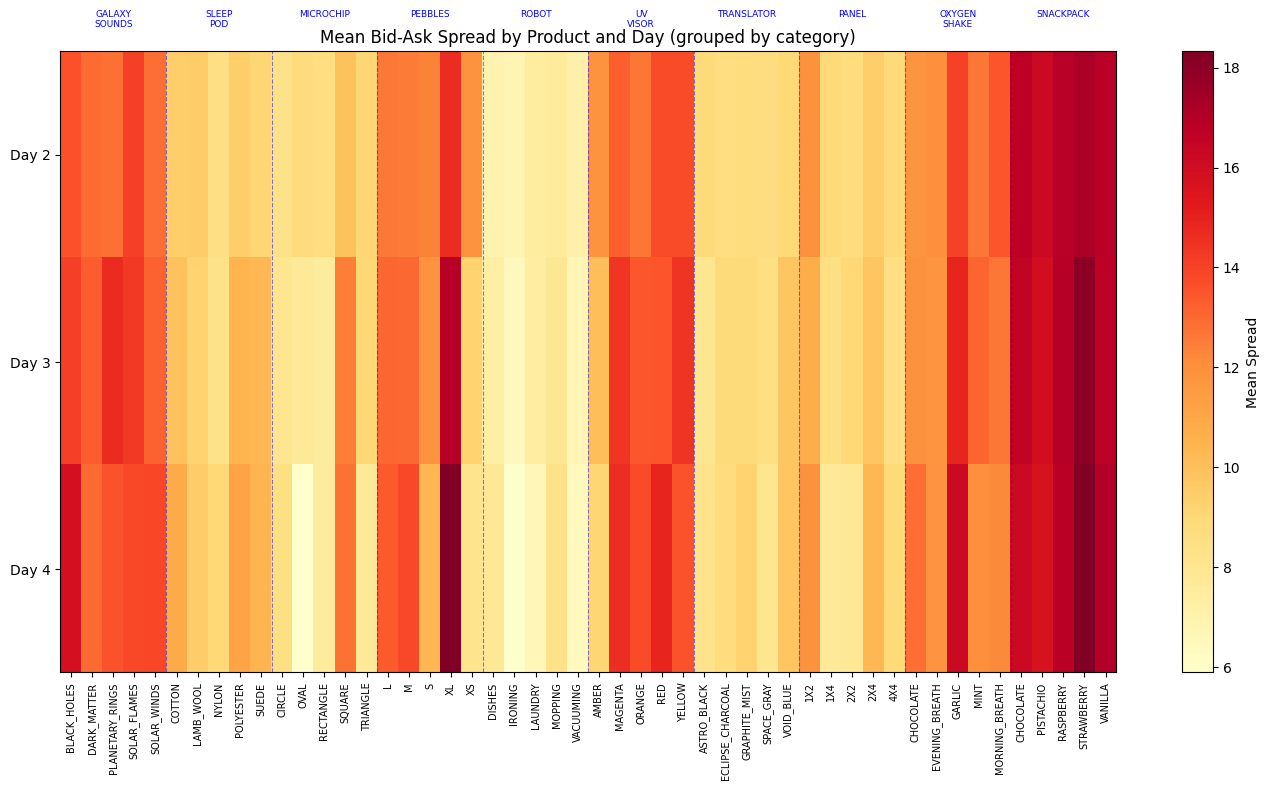

Heatmap saved.


In [5]:
fig, ax = plt.subplots(figsize=(14, 8))

cat_order = list(CATEGORIES.keys())
x_labels = []
x_vals = []
cat_spans = {}
idx = 0
for cat in cat_order:
    cat_spans[cat] = (idx, idx + len(CATEGORIES[cat]) - 1)
    for p in CATEGORIES[cat]:
        x_labels.append(p.split('_', len(cat.split('_')))[-1])  # short name
        x_vals.append(p)
        idx += 1

y_days = [2, 3, 4]
data_matrix = np.zeros((len(y_days), len(x_vals)))
for i, day in enumerate(y_days):
    dfday = df[df['day'] == day]
    means = dfday.groupby('product')['spread'].mean()
    for j, p in enumerate(x_vals):
        data_matrix[i, j] = means.get(p, np.nan)

im = ax.imshow(data_matrix, aspect='auto', cmap='YlOrRd')
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['Day 2', 'Day 3', 'Day 4'])
ax.set_xticks(range(len(x_vals)))
ax.set_xticklabels(x_labels, rotation=90, fontsize=7)
plt.colorbar(im, ax=ax, label='Mean Spread')

# Draw category dividers
for cat in cat_order:
    start, end = cat_spans[cat]
    ax.axvline(x=start - 0.5, color='blue', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.text(x=(start + end) / 2, y=-0.7, s=cat.replace('_', '\n'), ha='center', va='top', fontsize=6.5, color='blue')

ax.set_title('Mean Bid-Ask Spread by Product and Day (grouped by category)')
plt.tight_layout()
plt.savefig('/Users/bensinek/Documents/Coding/Prosperity4/notebooks/round_5/plots/02_spread_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print('Heatmap saved.')

## Cell 6 — Book imbalance at L1: per-product summary

L1 book imbalance = (bid_vol_1 - ask_vol_1) / (bid_vol_1 + ask_vol_1).  
Range: [-1, +1]. Value 0 = perfectly balanced.  
A persistent nonzero mean indicates structural side bias in NPC order posting.

In [6]:
# L1 imbalance statistics per product
imb_stats = df.groupby('product')['imbalance_l1'].agg(['mean','median','std','min','max']).round(5)
imb_stats['abs_mean'] = imb_stats['mean'].abs()
imb_stats = imb_stats.sort_values('abs_mean', ascending=False)

print('=== L1 Book Imbalance (all 3 days) — sorted by |mean| ===')
print(imb_stats.to_string())

# How many products have mean imbalance > 0.01 (1 tick biased)
biased = imb_stats[imb_stats['abs_mean'] > 0.01]
print(f'\nProducts with |mean L1 imbalance| > 0.01: {len(biased)}')
print(biased.index.tolist())

# Day-by-day stability of imbalance
imb_by_day = df.groupby(['product','day'])['imbalance_l1'].mean().unstack('day')
imb_by_day.columns = [f'day_{c}' for c in imb_by_day.columns]
print('\n=== L1 imbalance mean by day ===')
print(imb_by_day.sort_values('day_2').round(5).to_string())

=== L1 Book Imbalance (all 3 days) — sorted by |mean| ===
                                  mean  median      std      min      max  abs_mean
product                                                                            
ROBOT_LAUNDRY                 -0.00302     0.0  0.29698 -0.81818  0.81818   0.00302
ROBOT_VACUUMING                0.00299     0.0  0.28460 -0.81818  0.81818   0.00299
MICROCHIP_OVAL                 0.00249     0.0  0.23015 -0.81818  0.80952   0.00249
PANEL_1X4                     -0.00147     0.0  0.19361 -0.88889  0.89189   0.00147
PANEL_2X2                      0.00130     0.0  0.16943 -0.87879  0.88571   0.00130
ROBOT_MOPPING                 -0.00105     0.0  0.21662 -0.81818  0.81818   0.00105
MICROCHIP_CIRCLE               0.00081     0.0  0.17937 -0.80000  0.81818   0.00081
MICROCHIP_RECTANGLE           -0.00063     0.0  0.21743 -0.81818  0.80952   0.00063
TRANSLATOR_GRAPHITE_MIST       0.00060     0.0  0.11646 -0.88571  0.88235   0.00060
PEBBLES_XS        

## Cell 7 — Book imbalance at L2 and total depth asymmetry

Level-2 imbalance and total depth (L1+L2+L3) asymmetry, for products where L2 data is available.

In [7]:
# L2 imbalance (only ticks with L2 present)
imb_l2_stats = df.dropna(subset=['imbalance_l2']).groupby('product')['imbalance_l2'].agg(['mean','std','count']).round(5)
imb_l2_stats = imb_l2_stats.sort_values('mean', key=abs, ascending=False)

print('=== L2 Book Imbalance (ticks where L2 present) ===')
print(imb_l2_stats.to_string())

# Total depth asymmetry
depth_asym_stats = df.groupby('product')['depth_asymmetry_total'].agg(['mean','std']).round(5)
depth_asym_stats['abs_mean'] = depth_asym_stats['mean'].abs()
depth_asym_stats = depth_asym_stats.sort_values('abs_mean', ascending=False)

print('\n=== Total Depth Asymmetry (L1+L2+L3, all ticks) — sorted by |mean| ===')
print(depth_asym_stats.to_string())

# Check L1 vs total asymmetry correlation (do L2/L3 reinforce or cancel L1 imbalance?)
combined = pd.DataFrame({
    'imb_l1': df.groupby('product')['imbalance_l1'].mean(),
    'depth_asym_total': df.groupby('product')['depth_asymmetry_total'].mean()
})
corr = combined.corr().iloc[0, 1]
print(f'\nCorrelation between mean L1 imbalance and mean total depth asymmetry: {corr:.4f}')

=== L2 Book Imbalance (ticks where L2 present) ===
                                  mean      std  count
product                                               
ROBOT_LAUNDRY                  0.00082  0.05692  17858
PEBBLES_XS                     0.00053  0.05697  27775
PEBBLES_L                      0.00049  0.05700  30000
PEBBLES_S                      0.00049  0.05700  30000
PEBBLES_XL                     0.00049  0.05700  30000
PEBBLES_M                      0.00049  0.05700  30000
MICROCHIP_TRIANGLE             0.00047  0.04695  27157
SLEEP_POD_NYLON               -0.00039  0.05434  27437
PANEL_4X4                     -0.00036  0.05405  28532
TRANSLATOR_GRAPHITE_MIST      -0.00029  0.05400  29244
MICROCHIP_RECTANGLE            0.00029  0.04676  23152
SLEEP_POD_LAMB_WOOL           -0.00027  0.05357  29985
TRANSLATOR_SPACE_GRAY         -0.00027  0.05442  26659
ROBOT_VACUUMING               -0.00027  0.05710  16769
SLEEP_POD_POLYESTER           -0.00026  0.05358  29973
SLEEP_POD_SUED


Correlation between mean L1 imbalance and mean total depth asymmetry: -0.3487


## Cell 8 — Missing levels: fraction of ticks with L2 and L3

Some products may rarely post L2/L3 depth, implying a shallower book structure. Products with consistently missing L2/L3 may have more aggressive quoting patterns.

In [8]:
# Per-product, per-day fraction of ticks with L2 present
level_presence = df.groupby(['product','day']).agg(
    ticks=('spread', 'count'),
    l2_bid_frac=('has_l2_bid', 'mean'),
    l2_ask_frac=('has_l2_ask', 'mean'),
    l3_bid_frac=('has_l3_bid', 'mean'),
    l3_ask_frac=('has_l3_ask', 'mean'),
).round(4)

# Average across days
level_overall = df.groupby('product').agg(
    ticks=('spread', 'count'),
    l2_bid_frac=('has_l2_bid', 'mean'),
    l2_ask_frac=('has_l2_ask', 'mean'),
    l3_bid_frac=('has_l3_bid', 'mean'),
    l3_ask_frac=('has_l3_ask', 'mean'),
).round(4)

# Asymmetry: L2 bid presence vs ask presence
level_overall['l2_side_asymmetry'] = (level_overall['l2_bid_frac'] - level_overall['l2_ask_frac']).round(4)
level_overall['l3_side_asymmetry'] = (level_overall['l3_bid_frac'] - level_overall['l3_ask_frac']).round(4)

print('=== Level presence (fraction of ticks) — all days combined ===')
print(level_overall.sort_values('l2_bid_frac').to_string())

print('\nProducts with L2 bid presence < 50%:', level_overall[level_overall['l2_bid_frac'] < 0.5].index.tolist())
print('Products with L2 bid presence = 100%:', level_overall[level_overall['l2_bid_frac'] == 1.0].index.tolist())
print('\nSignificant L2 side asymmetry (|l2_side_asymmetry| > 0.01):')
print(level_overall[level_overall['l2_side_asymmetry'].abs() > 0.01][['l2_bid_frac','l2_ask_frac','l2_side_asymmetry']].to_string())

=== Level presence (fraction of ticks) — all days combined ===
                               ticks  l2_bid_frac  l2_ask_frac  l3_bid_frac  l3_ask_frac  l2_side_asymmetry  l3_side_asymmetry
product                                                                                                                       
ROBOT_VACUUMING                30000       0.7345       0.7414       0.0120       0.0120            -0.0069             0.0000
ROBOT_IRONING                  30000       0.7602       0.7606       0.0134       0.0126            -0.0004             0.0008
ROBOT_LAUNDRY                  30000       0.7933       0.7871       0.0128       0.0133             0.0062            -0.0005
MICROCHIP_OVAL                 30000       0.8157       0.8202       0.0101       0.0103            -0.0045            -0.0002
ROBOT_DISHES                   30000       0.8325       0.8342       0.0141       0.0138            -0.0017             0.0003
MICROCHIP_RECTANGLE            30000       0.873

## Cell 9 — Missing levels visualization

Bar chart showing L2 and L3 bid presence fraction per product, grouped by category.

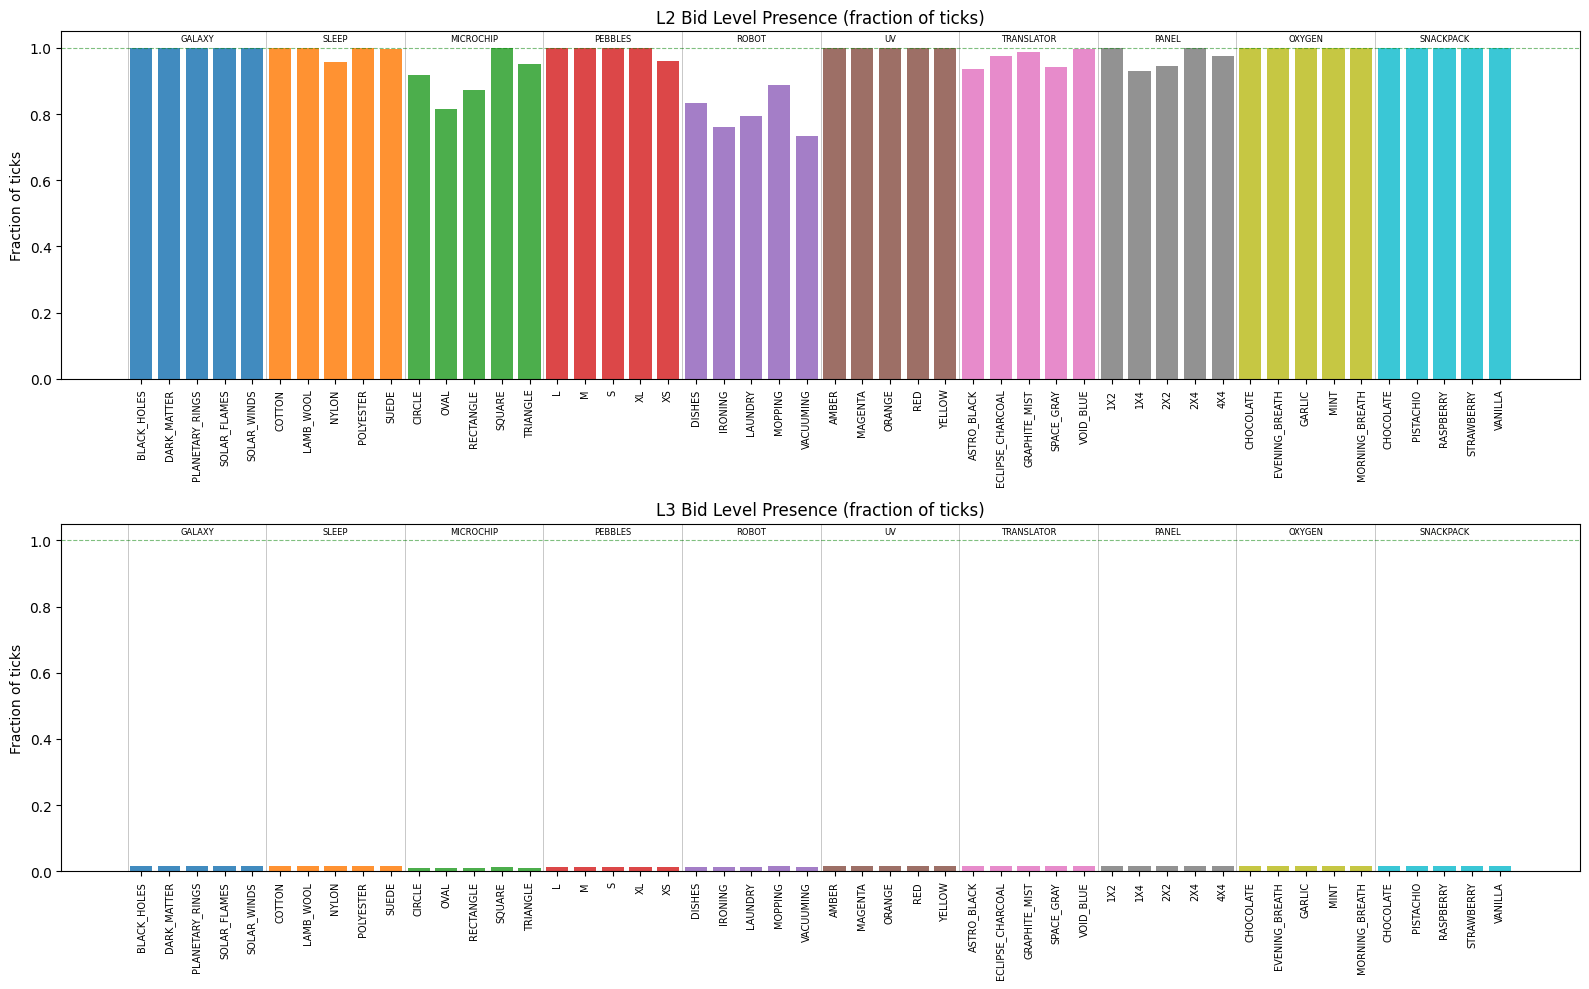

Level presence chart saved.


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=False)

for ax_idx, (level_col, title) in enumerate([('l2_bid_frac', 'L2 Bid Level Presence (fraction of ticks)'),
                                               ('l3_bid_frac', 'L3 Bid Level Presence (fraction of ticks)')]):
    ax = axes[ax_idx]
    ordered_products = []
    for cat in cat_order:
        ordered_products.extend(CATEGORIES[cat])
    
    vals = level_overall.reindex(ordered_products)[level_col].values
    colors = []
    cat_color_map = {
        'GALAXY_SOUNDS': '#1f77b4', 'SLEEP_POD': '#ff7f0e', 'MICROCHIP': '#2ca02c',
        'PEBBLES': '#d62728', 'ROBOT': '#9467bd', 'UV_VISOR': '#8c564b',
        'TRANSLATOR': '#e377c2', 'PANEL': '#7f7f7f', 'OXYGEN_SHAKE': '#bcbd22',
        'SNACKPACK': '#17becf'
    }
    for p in ordered_products:
        for cat, prods in CATEGORIES.items():
            if p in prods:
                colors.append(cat_color_map[cat])
                break
    
    short_labels = []
    for p in ordered_products:
        for cat in cat_order:
            if p in CATEGORIES[cat]:
                label = p.replace(cat + '_', '')
                short_labels.append(label)
                break
    
    bars = ax.bar(range(len(ordered_products)), vals, color=colors, alpha=0.85, edgecolor='none')
    ax.set_xticks(range(len(ordered_products)))
    ax.set_xticklabels(short_labels, rotation=90, fontsize=7)
    ax.set_ylabel('Fraction of ticks')
    ax.set_title(title)
    ax.axhline(y=1.0, color='green', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_ylim(0, 1.05)
    
    # Category dividers
    idx_pos = 0
    for cat in cat_order:
        ax.axvline(x=idx_pos - 0.5, color='black', linewidth=0.5, alpha=0.3)
        ax.text(x=idx_pos + len(CATEGORIES[cat]) / 2 - 0.5, y=1.02, s=cat.split('_')[0], fontsize=6, ha='center', color='black')
        idx_pos += len(CATEGORIES[cat])

plt.tight_layout()
plt.savefig('/Users/bensinek/Documents/Coding/Prosperity4/notebooks/round_5/plots/02_level_presence.png', dpi=120, bbox_inches='tight')
plt.show()
print('Level presence chart saved.')

## Cell 10 — Queue stickiness: how often does L1 price change tick-to-tick?

Queue stickiness = fraction of ticks where bid_price_1 does NOT change vs previous tick.  
High stickiness → NPC bot posts at same price for many ticks (sticky quote).  
Low stickiness → NPC bot frequently moves quotes (dynamic pricing).

In [10]:
# Sort by product + day + timestamp to compute tick-to-tick changes
df_sorted = df.sort_values(['product', 'day', 'timestamp']).copy()

# Compute tick-to-tick changes in bid_price_1 and ask_price_1
df_sorted['bid_change'] = df_sorted.groupby(['product', 'day'])['bid_price_1'].diff()
df_sorted['ask_change'] = df_sorted.groupby(['product', 'day'])['ask_price_1'].diff()
df_sorted['bid_unchanged'] = (df_sorted['bid_change'] == 0).astype(int)
df_sorted['ask_unchanged'] = (df_sorted['ask_change'] == 0).astype(int)
df_sorted['both_unchanged'] = ((df_sorted['bid_change'] == 0) & (df_sorted['ask_change'] == 0)).astype(int)

# Drop NaN (first tick per product-day)
df_stick = df_sorted.dropna(subset=['bid_change', 'ask_change'])

sticky_stats = df_stick.groupby('product').agg(
    bid_sticky_frac=('bid_unchanged', 'mean'),
    ask_sticky_frac=('ask_unchanged', 'mean'),
    both_sticky_frac=('both_unchanged', 'mean'),
    ticks=('bid_change', 'count')
).round(4)

sticky_stats = sticky_stats.sort_values('both_sticky_frac', ascending=False)

print('=== Queue stickiness (fraction of ticks with NO price change at L1) ===')
print(sticky_stats.to_string())

print(f'\nMost sticky products (both_sticky_frac > 0.95):')
print(sticky_stats[sticky_stats['both_sticky_frac'] > 0.95].index.tolist())
print(f'\nLeast sticky products (both_sticky_frac < 0.80):')
print(sticky_stats[sticky_stats['both_sticky_frac'] < 0.80].index.tolist())

=== Queue stickiness (fraction of ticks with NO price change at L1) ===
                               bid_sticky_frac  ask_sticky_frac  both_sticky_frac  ticks
product                                                                                 
ROBOT_IRONING                           0.4180           0.4183            0.4039  29997
OXYGEN_SHAKE_EVENING_BREATH             0.4045           0.4058            0.3918  29997
ROBOT_DISHES                            0.2925           0.2931            0.2729  29997
OXYGEN_SHAKE_CHOCOLATE                  0.1714           0.1720            0.1578  29997
SNACKPACK_PISTACHIO                     0.0741           0.0764            0.0496  29997
SNACKPACK_CHOCOLATE                     0.0610           0.0600            0.0399  29997
SNACKPACK_VANILLA                       0.0577           0.0593            0.0379  29997
SNACKPACK_RASPBERRY                     0.0472           0.0475            0.0310  29997
UV_VISOR_AMBER                        

## Cell 11 — Queue stickiness: day-by-day stability

Check whether stickiness is consistent across days 2/3/4 per product. Cross-day stability is needed for the 'replicable across all 3 days' criterion in the triage rubric.

In [11]:
sticky_by_day = df_stick.groupby(['product', 'day'])['both_unchanged'].mean().unstack('day')
sticky_by_day.columns = [f'day_{c}' for c in sticky_by_day.columns]
sticky_by_day['range_across_days'] = sticky_by_day.max(axis=1) - sticky_by_day.min(axis=1)
sticky_by_day = sticky_by_day.sort_values('range_across_days', ascending=False)

print('=== Stickiness by day (sorted by day-to-day range) ===')
print(sticky_by_day.round(4).to_string())

print(f'\nProducts with stickiness range > 0.05 across days (unstable): {sticky_by_day[sticky_by_day["range_across_days"] > 0.05].index.tolist()}')
print(f'Products with stickiness range < 0.01 across days (very stable): {sticky_by_day[sticky_by_day["range_across_days"] < 0.01].index.tolist()}')

=== Stickiness by day (sorted by day-to-day range) ===
                                day_2   day_3   day_4  range_across_days
product                                                                 
ROBOT_DISHES                   0.0275  0.0360  0.7551             0.7276
OXYGEN_SHAKE_CHOCOLATE         0.3816  0.0297  0.0622             0.3519
OXYGEN_SHAKE_EVENING_BREATH    0.4404  0.3715  0.3634             0.0770
ROBOT_IRONING                  0.4068  0.3831  0.4217             0.0386
UV_VISOR_AMBER                 0.0246  0.0314  0.0370             0.0124
SNACKPACK_PISTACHIO            0.0447  0.0480  0.0562             0.0115
UV_VISOR_YELLOW                0.0279  0.0176  0.0268             0.0103
MICROCHIP_OVAL                 0.0195  0.0180  0.0281             0.0101
SLEEP_POD_SUEDE                0.0297  0.0203  0.0203             0.0094
PANEL_2X2                      0.0281  0.0237  0.0325             0.0088
MICROCHIP_SQUARE               0.0177  0.0147  0.0102             0.0

## Cell 12 — Depth asymmetry patterns: per-product total depth distribution

Total depth per side and the bid/ask ratio distribution. Persistent depth asymmetry (more bid depth or more ask depth) may signal directional order posting by NPC bots.

In [12]:
# Total depth statistics
depth_stats = df.groupby('product').agg(
    mean_bid_depth=('total_bid_depth', 'mean'),
    mean_ask_depth=('total_ask_depth', 'mean'),
    std_bid_depth=('total_bid_depth', 'std'),
    std_ask_depth=('total_ask_depth', 'std'),
    mean_depth_asym=('depth_asymmetry_total', 'mean'),
    std_depth_asym=('depth_asymmetry_total', 'std'),
).round(3)

depth_stats['bid_ask_depth_ratio'] = (depth_stats['mean_bid_depth'] / depth_stats['mean_ask_depth']).round(4)
depth_stats = depth_stats.sort_values('mean_depth_asym', ascending=False)

print('=== Depth statistics per product (all 3 days) ===')
print(depth_stats.to_string())

# Products with persistent bid-heavy depth
bid_heavy = depth_stats[depth_stats['mean_depth_asym'] > 0.02]
ask_heavy = depth_stats[depth_stats['mean_depth_asym'] < -0.02]
print(f'\nPersistently bid-heavy (mean_depth_asym > 0.02): {bid_heavy.index.tolist()}')
print(f'Persistently ask-heavy (mean_depth_asym < -0.02): {ask_heavy.index.tolist()}')

=== Depth statistics per product (all 3 days) ===
                               mean_bid_depth  mean_ask_depth  std_bid_depth  std_ask_depth  mean_depth_asym  std_depth_asym  bid_ask_depth_ratio
product                                                                                                                                          
GALAXY_SOUNDS_BLACK_HOLES              49.568          49.567          5.518          5.524              0.0           0.008               1.0000
SNACKPACK_RASPBERRY                    79.991          79.991          8.581          8.591              0.0           0.005               1.0000
ROBOT_LAUNDRY                          16.051          16.050          2.071          2.064             -0.0           0.021               1.0001
ROBOT_MOPPING                          16.051          16.050          2.071          2.064             -0.0           0.021               1.0001
ROBOT_VACUUMING                        16.051          16.050          2.0

## Cell 13 — Depth asymmetry: visualization across categories

Horizontal bar chart of mean depth asymmetry (positive = bid-heavy, negative = ask-heavy).

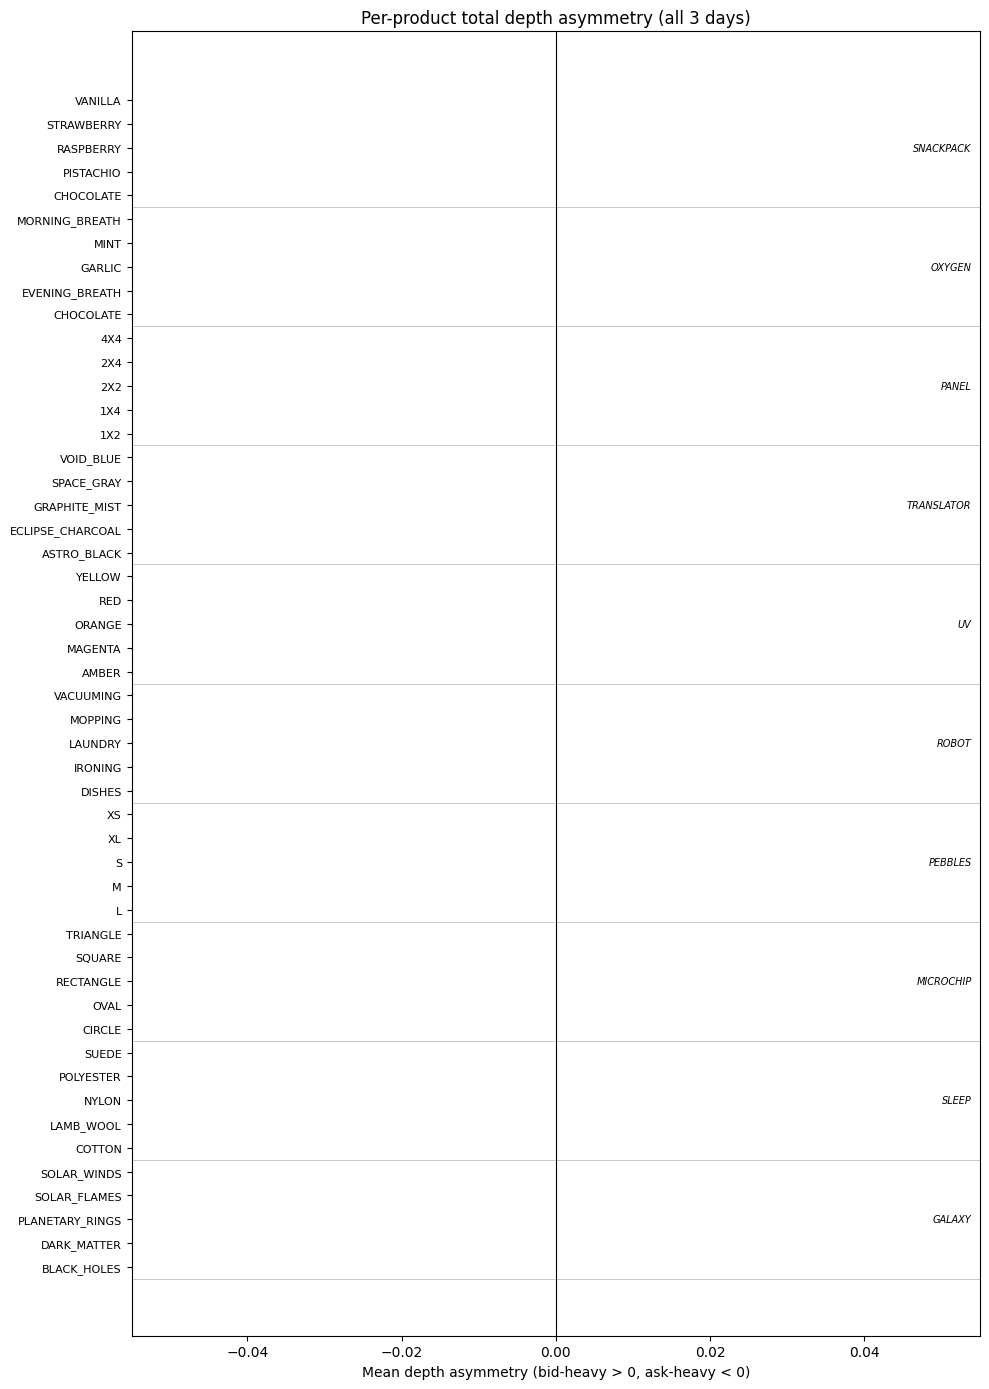

Depth asymmetry chart saved.


In [13]:
fig, ax = plt.subplots(figsize=(10, 14))

ordered_products = []
for cat in cat_order:
    ordered_products.extend(CATEGORIES[cat])

vals = depth_stats.reindex(ordered_products)['mean_depth_asym'].values
colors_bar = ['#e74c3c' if v > 0 else '#3498db' for v in vals]

# Short labels
short_labels = []
for p in ordered_products:
    for cat in cat_order:
        if p in CATEGORIES[cat]:
            short_labels.append(p.replace(cat + '_', ''))
            break

ax.barh(range(len(ordered_products)), vals, color=colors_bar, alpha=0.8, edgecolor='none')
ax.set_yticks(range(len(ordered_products)))
ax.set_yticklabels(short_labels, fontsize=8)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Mean depth asymmetry (bid-heavy > 0, ask-heavy < 0)')
ax.set_title('Per-product total depth asymmetry (all 3 days)')

# Category separators
idx_pos = 0
for cat in cat_order:
    ax.axhline(y=idx_pos - 0.5, color='black', linewidth=0.5, alpha=0.3)
    ax.text(x=ax.get_xlim()[1] * 0.98, y=idx_pos + len(CATEGORIES[cat]) / 2 - 0.5, s=cat.split('_')[0],
            ha='right', va='center', fontsize=7, color='black', style='italic')
    idx_pos += len(CATEGORIES[cat])

plt.tight_layout()
plt.savefig('/Users/bensinek/Documents/Coding/Prosperity4/notebooks/round_5/plots/02_depth_asymmetry.png', dpi=120, bbox_inches='tight')
plt.show()
print('Depth asymmetry chart saved.')

## Cell 14 — Spread regime: spread tick distribution per product

Count the fraction of ticks at each spread value. Products that spend >90% of ticks at a single spread value have a rigid quoting regime — the NPC bot is deterministic in its width.

In [14]:
# Fraction of ticks at modal spread
def modal_fraction(series):
    vc = series.value_counts(normalize=True)
    return vc.iloc[0] if len(vc) > 0 else np.nan

spread_modal_frac = df.groupby('product')['spread'].apply(modal_fraction).round(4)
spread_mode_val = df.groupby('product')['spread'].apply(lambda x: x.mode()[0])

modal_df = pd.DataFrame({'modal_spread': spread_mode_val, 'modal_frac': spread_modal_frac})
modal_df = modal_df.sort_values('modal_frac', ascending=False)

print('=== Modal spread and fraction of ticks at modal spread ===')
print(modal_df.to_string())

rigid_spread = modal_df[modal_df['modal_frac'] > 0.90]
print(f'\nProducts with >90% of ticks at modal spread: {rigid_spread.index.tolist()}')
print(f'Count: {len(rigid_spread)}')

variable_spread = modal_df[modal_df['modal_frac'] < 0.50]
print(f'\nProducts with <50% at modal spread (variable regime): {variable_spread.index.tolist()}')
print(f'Count: {len(variable_spread)}')

=== Modal spread and fraction of ticks at modal spread ===
                               modal_spread  modal_frac
product                                                
OXYGEN_SHAKE_EVENING_BREATH              12      0.9341
SNACKPACK_RASPBERRY                      17      0.7269
ROBOT_IRONING                             6      0.7243
SNACKPACK_VANILLA                        17      0.7185
TRANSLATOR_ECLIPSE_CHARCOAL               9      0.7160
TRANSLATOR_GRAPHITE_MIST                  9      0.6999
SNACKPACK_PISTACHIO                      16      0.6984
PANEL_4X4                                 9      0.6663
OXYGEN_SHAKE_CHOCOLATE                   12      0.6645
SNACKPACK_CHOCOLATE                      17      0.6596
ROBOT_VACUUMING                           7      0.6448
GALAXY_SOUNDS_DARK_MATTER                13      0.6178
MICROCHIP_CIRCLE                          8      0.6073
TRANSLATOR_VOID_BLUE                     10      0.5862
OXYGEN_SHAKE_MINT                        13  

## Cell 15 — Spread distribution by category: violin plots

Violin plots showing per-category spread distribution across all days and products.

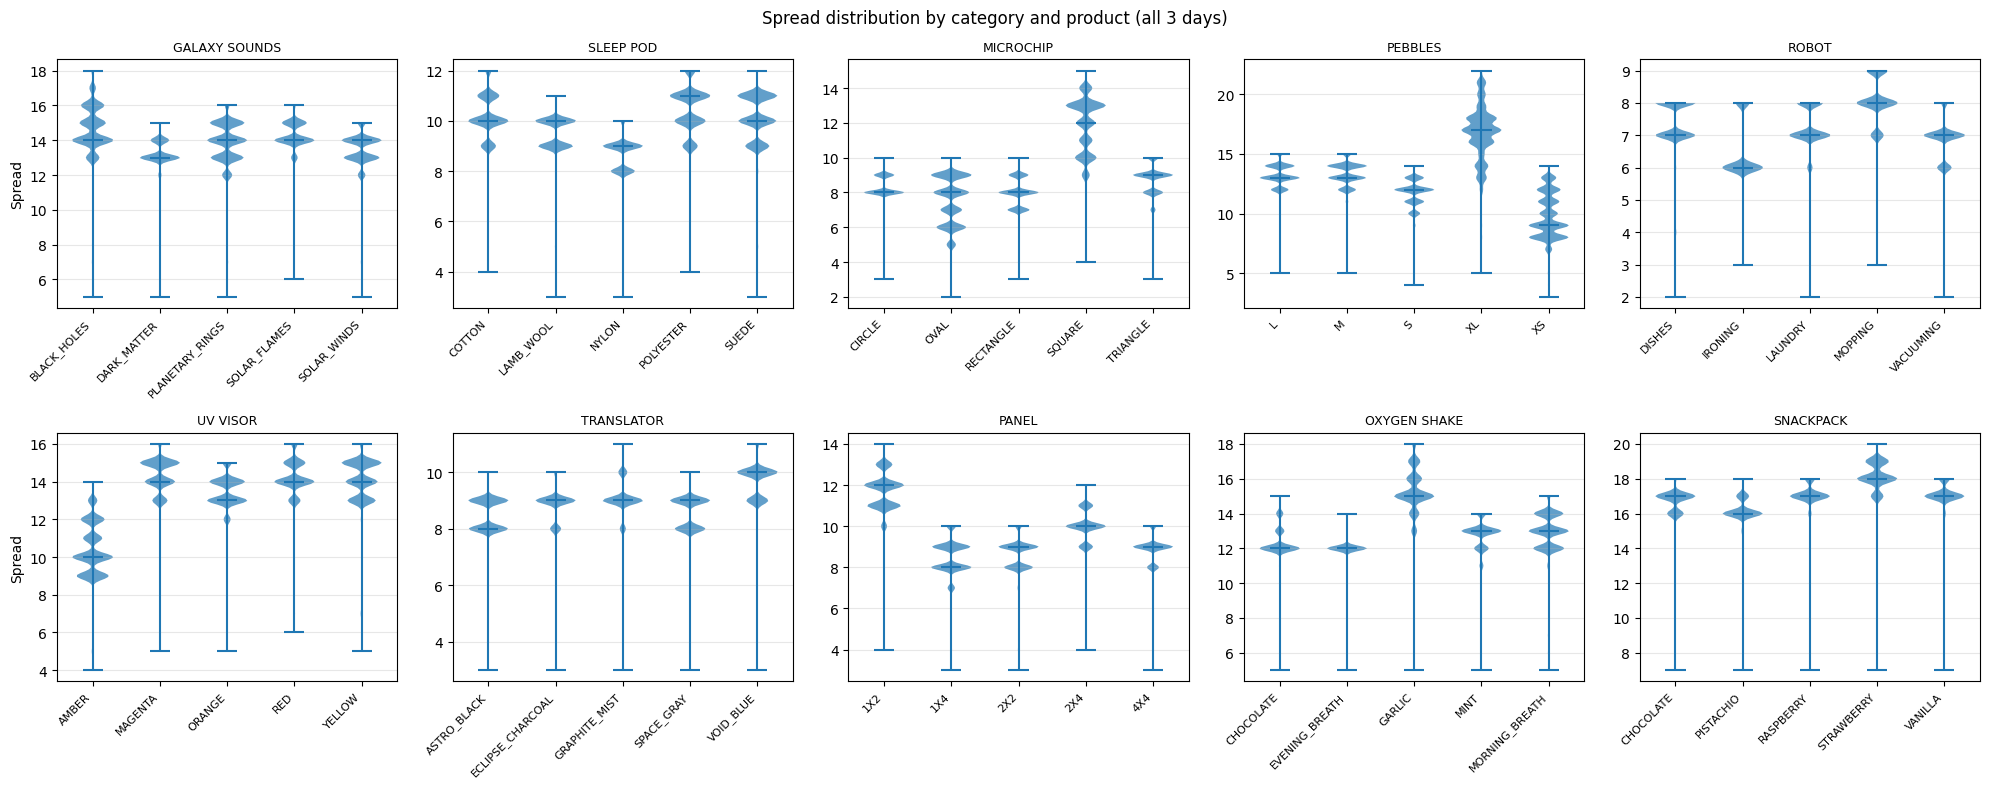

Violin plots saved.


In [15]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=False)
axes = axes.flatten()

for i, cat in enumerate(cat_order):
    ax = axes[i]
    prods = CATEGORIES[cat]
    data_by_prod = [df[df['product'] == p]['spread'].values for p in prods]
    # short names
    short = [p.replace(cat + '_', '') for p in prods]
    
    if all(len(d) > 0 for d in data_by_prod):
        parts = ax.violinplot(data_by_prod, positions=range(len(prods)), widths=0.6, showmedians=True)
        for body in parts['bodies']:
            body.set_alpha(0.7)
    
    ax.set_xticks(range(len(prods)))
    ax.set_xticklabels(short, rotation=45, ha='right', fontsize=8)
    ax.set_title(cat.replace('_', ' '), fontsize=9)
    ax.set_ylabel('Spread' if i % 5 == 0 else '')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Spread distribution by category and product (all 3 days)', fontsize=12)
plt.tight_layout()
plt.savefig('/Users/bensinek/Documents/Coding/Prosperity4/notebooks/round_5/plots/02_spread_violin.png', dpi=120, bbox_inches='tight')
plt.show()
print('Violin plots saved.')

## Cell 16 — Book imbalance: distribution plots

For each category, plot the distribution of L1 imbalance across all ticks. Categories with non-zero mean imbalance consistently suggest structural directional bias in NPC book posting.

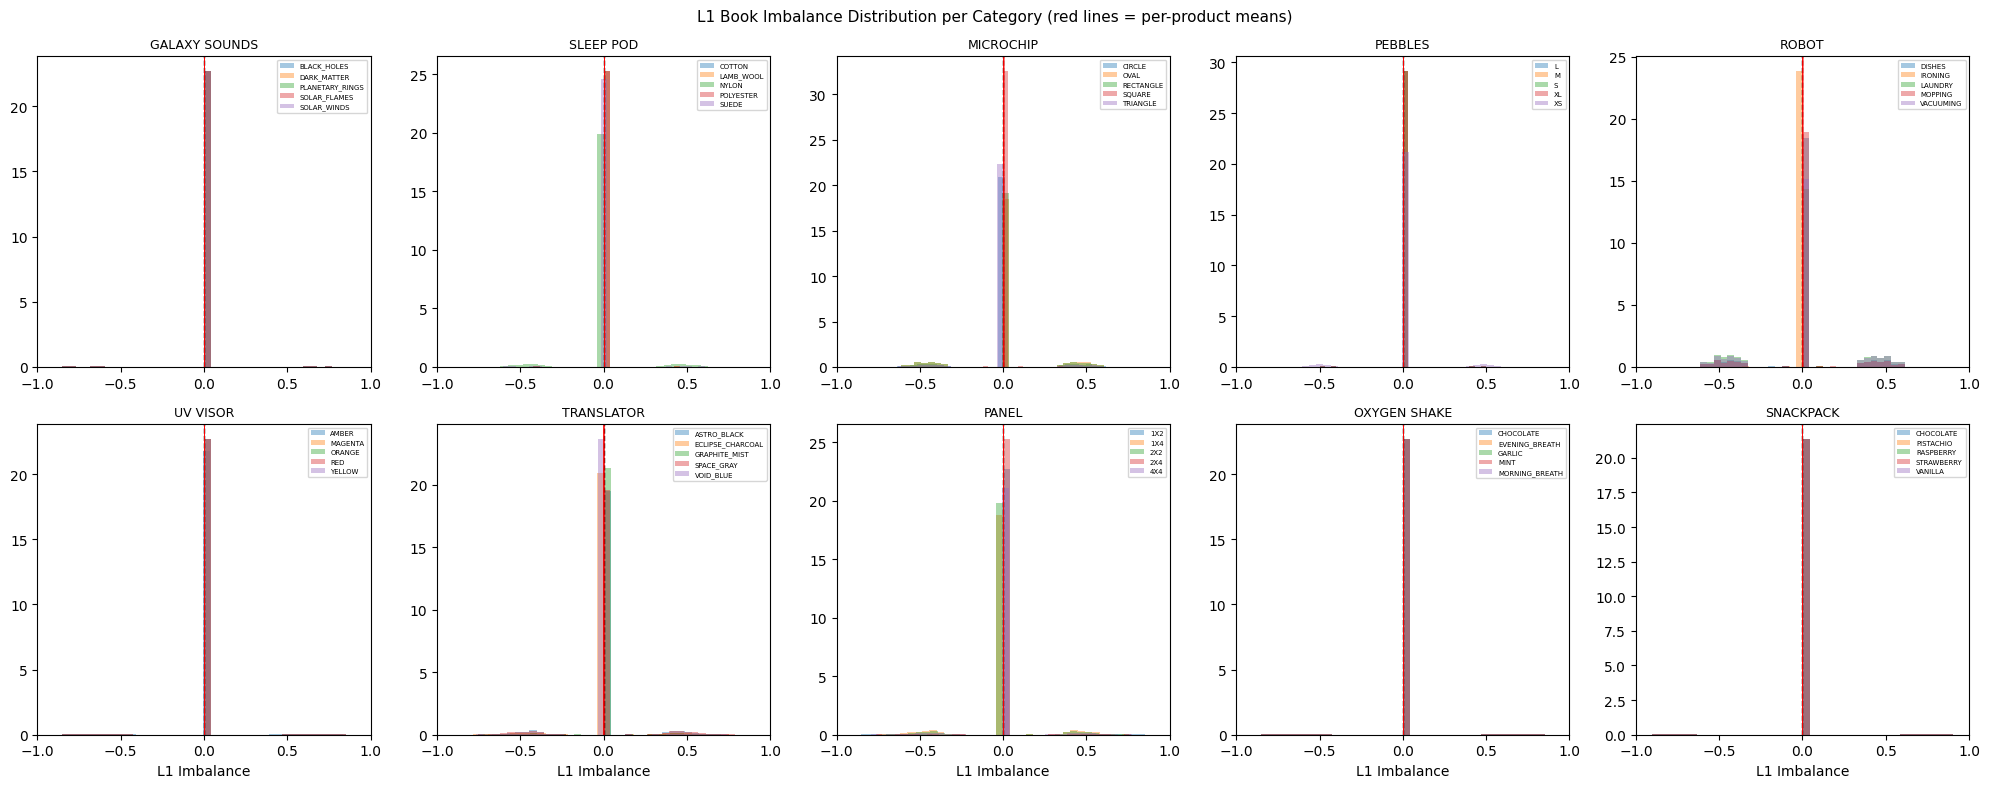

Imbalance distribution plots saved.


In [16]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, cat in enumerate(cat_order):
    ax = axes[i]
    prods = CATEGORIES[cat]
    
    for p in prods:
        imb = df[df['product'] == p]['imbalance_l1']
        ax.hist(imb, bins=40, alpha=0.4, density=True, label=p.replace(cat+'_', ''))
    
    ax.axvline(x=0, color='black', linewidth=1, linestyle='--')
    # Mark each product's mean
    for p in prods:
        mean_imb = df[df['product'] == p]['imbalance_l1'].mean()
        ax.axvline(x=mean_imb, color='red', linewidth=0.5, alpha=0.7)
    
    ax.set_title(cat.replace('_', ' '), fontsize=9)
    ax.set_xlabel('L1 Imbalance' if i >= 5 else '')
    ax.legend(fontsize=5, loc='upper right')
    ax.set_xlim(-1, 1)

plt.suptitle('L1 Book Imbalance Distribution per Category (red lines = per-product means)', fontsize=11)
plt.tight_layout()
plt.savefig('/Users/bensinek/Documents/Coding/Prosperity4/notebooks/round_5/plots/02_imbalance_dist.png', dpi=120, bbox_inches='tight')
plt.show()
print('Imbalance distribution plots saved.')

## Cell 17 — Volume symmetry within products: bid_vol_1 vs ask_vol_1 over time

For a selection of products with extreme depth asymmetry, plot bid vs ask volume at L1 over time to verify the asymmetry is persistent.

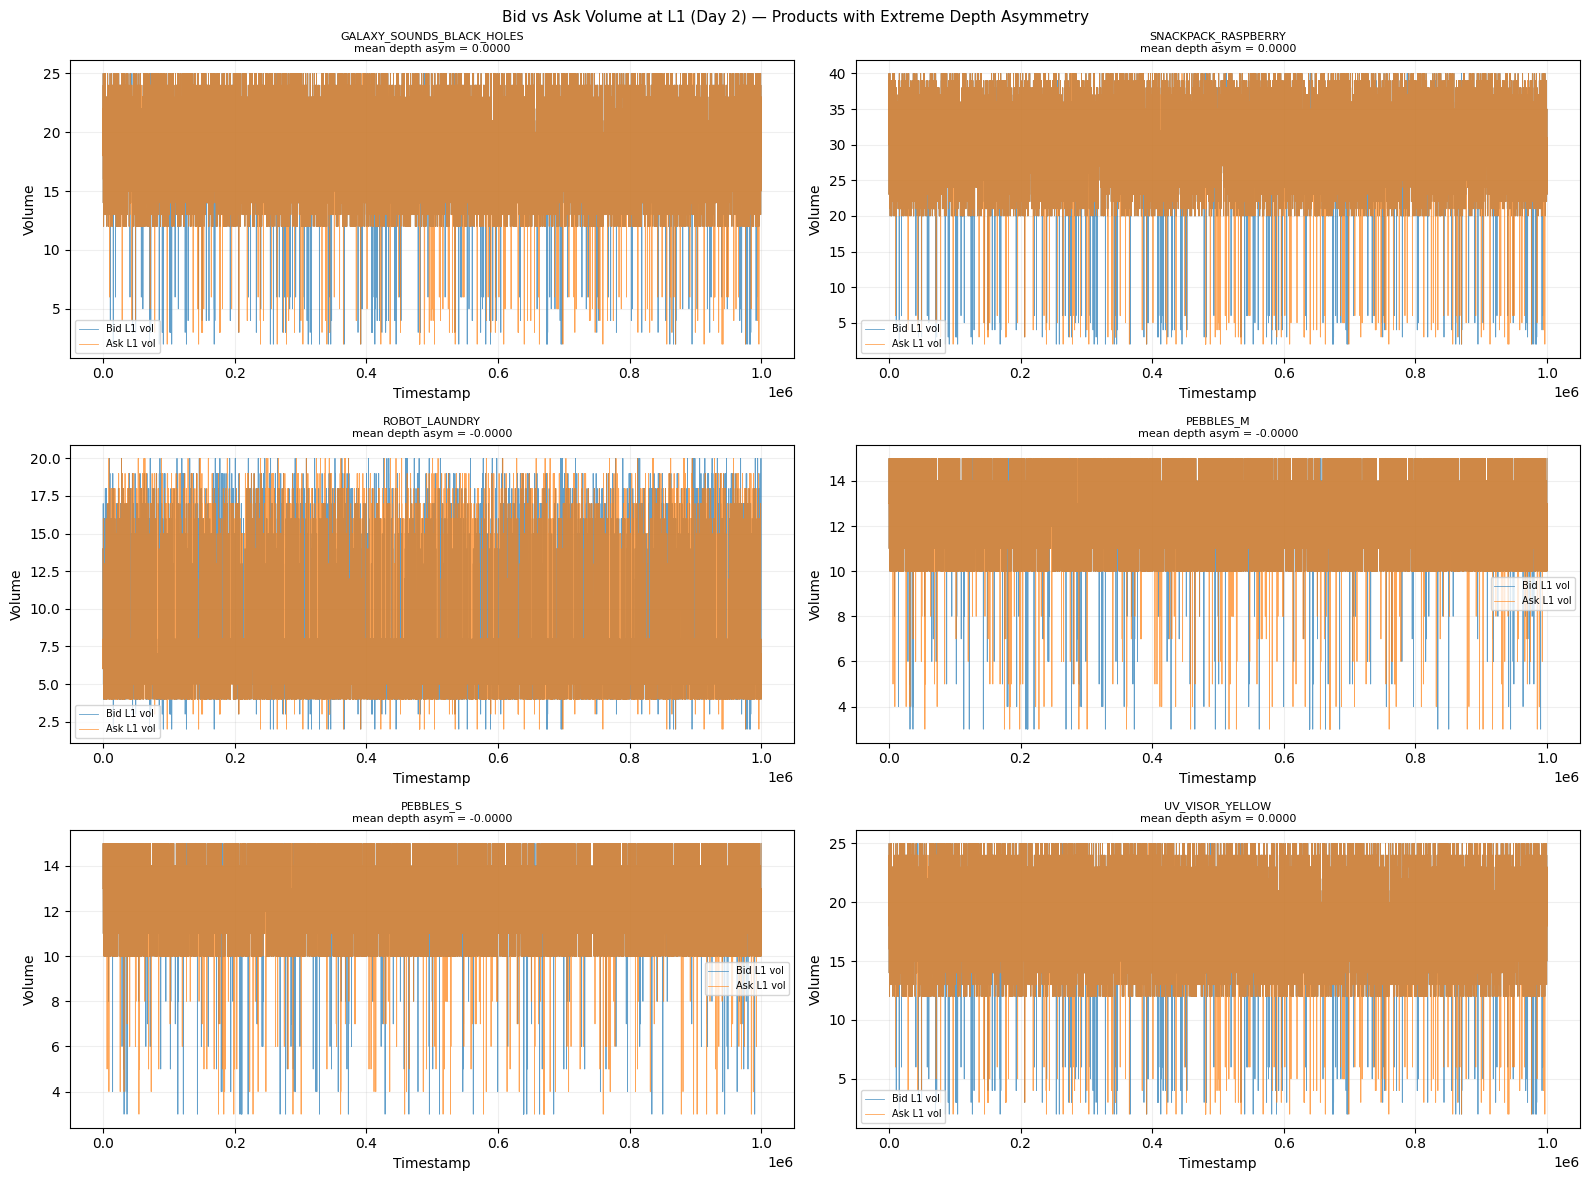

Volume asymmetry timeseries saved.


In [17]:
# Identify top 6 products by absolute mean depth asymmetry for visualization
top_asym_prods = depth_stats.head(3).index.tolist() + depth_stats.tail(3).index.tolist()

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for i, prod in enumerate(top_asym_prods):
    ax = axes[i]
    # Use day 2 only for clarity
    sub = df[(df['product'] == prod) & (df['day'] == 2)].sort_values('timestamp')
    ax.plot(sub['timestamp'], sub['bid_volume_1'], label='Bid L1 vol', alpha=0.7, linewidth=0.6)
    ax.plot(sub['timestamp'], sub['ask_volume_1'], label='Ask L1 vol', alpha=0.7, linewidth=0.6)
    mean_asym = depth_stats.loc[prod, 'mean_depth_asym']
    ax.set_title(f'{prod}\nmean depth asym = {mean_asym:.4f}', fontsize=8)
    ax.legend(fontsize=7)
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Volume')
    ax.grid(alpha=0.2)

plt.suptitle('Bid vs Ask Volume at L1 (Day 2) — Products with Extreme Depth Asymmetry', fontsize=11)
plt.tight_layout()
plt.savefig('/Users/bensinek/Documents/Coding/Prosperity4/notebooks/round_5/plots/02_volume_asym_timeseries.png', dpi=120, bbox_inches='tight')
plt.show()
print('Volume asymmetry timeseries saved.')

## Cell 18 — Queue stickiness visualization

Bar chart of bid L1 stickiness fraction across all products, grouped by category.

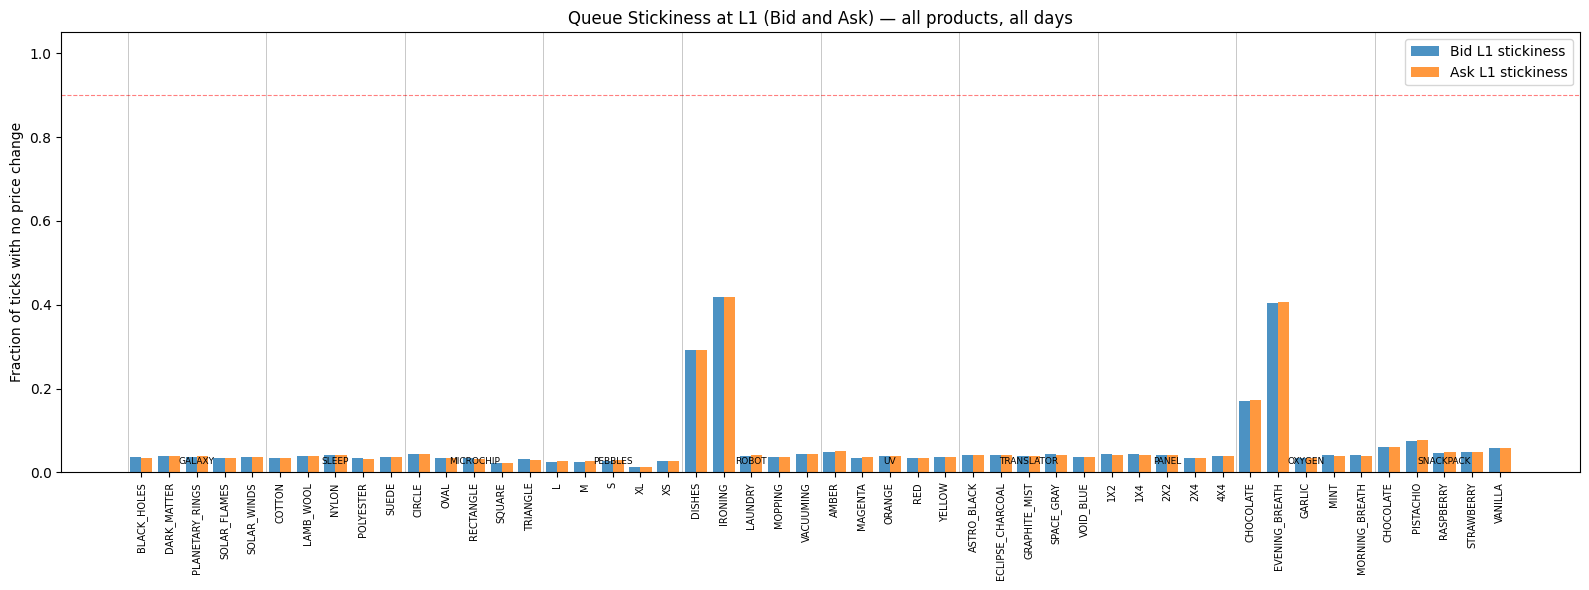

Queue stickiness chart saved.


In [18]:
fig, ax = plt.subplots(figsize=(16, 6))

ordered_products = []
for cat in cat_order:
    ordered_products.extend(CATEGORIES[cat])

bid_sticky = sticky_stats.reindex(ordered_products)['bid_sticky_frac'].values
ask_sticky = sticky_stats.reindex(ordered_products)['ask_sticky_frac'].values

x = np.arange(len(ordered_products))
width = 0.4
ax.bar(x - width/2, bid_sticky, width=width, label='Bid L1 stickiness', alpha=0.8)
ax.bar(x + width/2, ask_sticky, width=width, label='Ask L1 stickiness', alpha=0.8)

short_labels = []
for p in ordered_products:
    for cat in cat_order:
        if p in CATEGORIES[cat]:
            short_labels.append(p.replace(cat + '_', ''))
            break

ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=90, fontsize=7)
ax.set_ylabel('Fraction of ticks with no price change')
ax.set_title('Queue Stickiness at L1 (Bid and Ask) — all products, all days')
ax.legend()
ax.axhline(y=0.9, color='red', linewidth=0.8, linestyle='--', alpha=0.5, label='90% line')

# Category dividers
idx_pos = 0
for cat in cat_order:
    ax.axvline(x=idx_pos - 0.5, color='black', linewidth=0.5, alpha=0.3)
    ax.text(x=idx_pos + len(CATEGORIES[cat]) / 2 - 0.5, y=0.02, s=cat.split('_')[0], ha='center', fontsize=6.5, color='black')
    idx_pos += len(CATEGORIES[cat])

ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('/Users/bensinek/Documents/Coding/Prosperity4/notebooks/round_5/plots/02_queue_stickiness.png', dpi=120, bbox_inches='tight')
plt.show()
print('Queue stickiness chart saved.')

## Cell 19 — Spread distribution: count distinct spread values per product

Products with very few distinct spread values have rigid quote widths. Products with many distinct spread values have dynamic pricing.

In [19]:
# Number of distinct spread values per product
spread_distinct = df.groupby('product')['spread'].nunique().sort_values()
print('=== Distinct spread values per product ===')
print(spread_distinct.to_string())

print(f'\nProducts with <= 5 distinct spreads: {spread_distinct[spread_distinct <= 5].index.tolist()}')
print(f'Products with >= 10 distinct spreads: {spread_distinct[spread_distinct >= 10].index.tolist()}')

# Also: spread value_counts for the most rigid products
most_rigid = spread_distinct.head(5).index.tolist()
print('\nSpread value_counts for the 5 most rigid products:')
for p in most_rigid:
    vc = df[df['product'] == p]['spread'].value_counts(normalize=True).round(4)
    print(f'  {p}: {vc.to_dict()}')

=== Distinct spread values per product ===
product
ROBOT_IRONING                     4
OXYGEN_SHAKE_EVENING_BREATH       6
ROBOT_MOPPING                     6
PANEL_4X4                         7
TRANSLATOR_ECLIPSE_CHARCOAL       7
ROBOT_DISHES                      7
ROBOT_LAUNDRY                     7
SNACKPACK_RASPBERRY               7
SNACKPACK_VANILLA                 7
ROBOT_VACUUMING                   7
SNACKPACK_PISTACHIO               8
SLEEP_POD_LAMB_WOOL               8
TRANSLATOR_ASTRO_BLACK            8
SLEEP_POD_NYLON                   8
TRANSLATOR_SPACE_GRAY             8
SNACKPACK_CHOCOLATE               8
PANEL_2X2                         8
TRANSLATOR_VOID_BLUE              8
MICROCHIP_RECTANGLE               8
GALAXY_SOUNDS_DARK_MATTER         8
TRANSLATOR_GRAPHITE_MIST          8
GALAXY_SOUNDS_SOLAR_WINDS         8
MICROCHIP_CIRCLE                  8
PANEL_1X4                         8
UV_VISOR_ORANGE                   8
PANEL_2X4                         8
OXYGEN_SHAKE_

  ROBOT_MOPPING: {8: 0.5286, 9: 0.2698, 7: 0.1683, 4: 0.0167, 5: 0.0093, 3: 0.0072}
  PANEL_4X4: {9: 0.6663, 8: 0.1991, 10: 0.1014, 4: 0.0158, 5: 0.015, 3: 0.0019, 6: 0.0006}
  TRANSLATOR_ECLIPSE_CHARCOAL: {9: 0.716, 8: 0.1992, 10: 0.0516, 4: 0.0164, 5: 0.0151, 3: 0.0015, 6: 0.0003}


## Cell 20 — Cross-category summary table

Aggregate all microstructure lenses into a single per-product summary table for downstream synthesis.

In [20]:
# Assign category labels
cat_map = {}
for cat, prods in CATEGORIES.items():
    for p in prods:
        cat_map[p] = cat

summary = pd.DataFrame({'category': pd.Series(cat_map)})

# Spread metrics
summary['mean_spread'] = spread_overall['mean']
summary['spread_cv'] = spread_overall['cv']
summary['spread_modal_frac'] = modal_df['modal_frac']
summary['spread_n_distinct'] = spread_distinct

# Imbalance metrics
summary['imb_l1_mean'] = imb_stats['mean']
summary['imb_l1_std'] = imb_stats['std']

# Depth asymmetry
summary['depth_asym_mean'] = depth_stats['mean_depth_asym']
summary['depth_asym_std'] = depth_stats['std_depth_asym']

# Level presence
summary['l2_bid_frac'] = level_overall['l2_bid_frac']
summary['l3_bid_frac'] = level_overall['l3_bid_frac']

# Queue stickiness
summary['bid_stickiness'] = sticky_stats['bid_sticky_frac']
summary['ask_stickiness'] = sticky_stats['ask_sticky_frac']
summary['both_stickiness'] = sticky_stats['both_sticky_frac']

summary = summary.sort_values(['category', 'mean_spread'])

print('=== Full microstructure summary table ===')
print(summary.round(4).to_string())

# Save as CSV (optional reference)
summary.round(4).to_csv('/Users/bensinek/Documents/Coding/Prosperity4/notebooks/round_5/plots/02_summary_table.csv')
print('\nSummary table saved to plots/02_summary_table.csv')

=== Full microstructure summary table ===
                                    category  mean_spread  spread_cv  spread_modal_frac  spread_n_distinct  imb_l1_mean  imb_l1_std  depth_asym_mean  depth_asym_std  l2_bid_frac  l3_bid_frac  bid_stickiness  ask_stickiness  both_stickiness
GALAXY_SOUNDS_DARK_MATTER      GALAXY_SOUNDS       13.051     0.1011             0.6178                  8      -0.0002      0.1185              0.0           0.008       1.0000       0.0168          0.0400          0.0387           0.0252
GALAXY_SOUNDS_SOLAR_WINDS      GALAXY_SOUNDS       13.301     0.1077             0.4230                  8      -0.0002      0.1185              0.0           0.008       1.0000       0.0168          0.0371          0.0375           0.0231
GALAXY_SOUNDS_PLANETARY_RINGS  GALAXY_SOUNDS       13.690     0.1170             0.3163                 10      -0.0002      0.1185              0.0           0.008       1.0000       0.0168          0.0359          0.0380           0.022

## Cell 21 — Key findings per category

Summarize the microstructure signal by category, citing computed numbers.

In [21]:
print('=== KEY MICROSTRUCTURE FINDINGS BY CATEGORY ===')
print()

for cat in cat_order:
    prods = CATEGORIES[cat]
    cat_data = summary[summary['category'] == cat]
    print(f'--- {cat} ---')
    print(f'  Mean spread range: {cat_data["mean_spread"].min():.2f} – {cat_data["mean_spread"].max():.2f}')
    print(f'  Spread CV range: {cat_data["spread_cv"].min():.4f} – {cat_data["spread_cv"].max():.4f}')
    print(f'  Spread modal fraction range: {cat_data["spread_modal_frac"].min():.3f} – {cat_data["spread_modal_frac"].max():.3f}')
    print(f'  L1 imbalance mean range: {cat_data["imb_l1_mean"].min():.5f} – {cat_data["imb_l1_mean"].max():.5f}')
    print(f'  L2 bid presence range: {cat_data["l2_bid_frac"].min():.4f} – {cat_data["l2_bid_frac"].max():.4f}')
    print(f'  Bid stickiness range: {cat_data["bid_stickiness"].min():.4f} – {cat_data["bid_stickiness"].max():.4f}')
    print(f'  Depth asym mean range: {cat_data["depth_asym_mean"].min():.5f} – {cat_data["depth_asym_mean"].max():.5f}')
    print()

# Top outliers across all metrics
print('=== OUTLIER PRODUCTS ===')
print(f'Most rigid spread (>90% at mode): {summary[summary["spread_modal_frac"] > 0.9].index.tolist()}')
print(f'Widest spreads (mean > 16): {summary[summary["mean_spread"] > 16].index.tolist()}')
print(f'Tightest spreads (mean < 8): {summary[summary["mean_spread"] < 8].index.tolist()}')
print(f'Most imbalanced L1 (|mean| > 0.005): {summary[summary["imb_l1_mean"].abs() > 0.005].index.tolist()}')
print(f'Most sticky (both > 0.95): {summary[summary["both_stickiness"] > 0.95].index.tolist()}')
print(f'Least sticky (both < 0.80): {summary[summary["both_stickiness"] < 0.80].index.tolist()}')
print(f'Lowest L2 presence (<30% of ticks): {summary[summary["l2_bid_frac"] < 0.30].index.tolist()}')

=== KEY MICROSTRUCTURE FINDINGS BY CATEGORY ===

--- GALAXY_SOUNDS ---
  Mean spread range: 13.05 – 14.51
  Spread CV range: 0.1011 – 0.1233
  Spread modal fraction range: 0.316 – 0.618
  L1 imbalance mean range: -0.00025 – -0.00025
  L2 bid presence range: 1.0000 – 1.0000
  Bid stickiness range: 0.0354 – 0.0400
  Depth asym mean range: 0.00000 – 0.00000

--- SLEEP_POD ---
  Mean spread range: 8.56 – 10.30
  Spread CV range: 0.1078 – 0.1251
  Spread modal fraction range: 0.371 – 0.563
  L1 imbalance mean range: -0.00023 – 0.00004
  L2 bid presence range: 0.9561 – 0.9999
  Bid stickiness range: 0.0341 – 0.0417
  Depth asym mean range: 0.00000 – 0.00000

--- MICROCHIP ---
  Mean spread range: 7.45 – 11.72
  Spread CV range: 0.1077 – 0.1921
  Spread modal fraction range: 0.287 – 0.607
  L1 imbalance mean range: -0.00063 – 0.00249
  L2 bid presence range: 0.8157 – 0.9998
  Bid stickiness range: 0.0214 – 0.0443
  Depth asym mean range: -0.00000 – -0.00000

--- PEBBLES ---
  Mean spread rang

## Cell 22 — Volume stickiness: does L1 volume change even when price does not?

Even if the price at L1 is sticky, the volume posted may fluctuate. Volume stickiness = fraction of ticks where bid_volume_1 does NOT change vs previous tick, conditional on price being sticky.

In [22]:
df_sorted2 = df.sort_values(['product', 'day', 'timestamp']).copy()
df_sorted2['bid_vol_change'] = df_sorted2.groupby(['product', 'day'])['bid_volume_1'].diff()
df_sorted2['ask_vol_change'] = df_sorted2.groupby(['product', 'day'])['ask_volume_1'].diff()
df_sorted2 = df_sorted2.dropna(subset=['bid_vol_change'])

df_sorted2['bid_vol_unchanged'] = (df_sorted2['bid_vol_change'] == 0).astype(int)
df_sorted2['ask_vol_unchanged'] = (df_sorted2['ask_vol_change'] == 0).astype(int)

vol_stick_stats = df_sorted2.groupby('product').agg(
    bid_vol_sticky_frac=('bid_vol_unchanged', 'mean'),
    ask_vol_sticky_frac=('ask_vol_unchanged', 'mean'),
).round(4).sort_values('bid_vol_sticky_frac', ascending=False)

print('=== Volume stickiness at L1 (fraction of ticks with no volume change) ===')
print(vol_stick_stats.to_string())

# Combine price + volume stickiness
full_stick = vol_stick_stats.merge(sticky_stats[['bid_sticky_frac','ask_sticky_frac']], left_index=True, right_index=True)
full_stick['bid_price_vol_both_sticky'] = (full_stick['bid_vol_sticky_frac'] * full_stick['bid_sticky_frac']).round(4)
print('\nProducts with both price AND volume sticky at bid L1 (product):')
print(full_stick.sort_values('bid_price_vol_both_sticky', ascending=False)[['bid_sticky_frac','bid_vol_sticky_frac','bid_price_vol_both_sticky']].head(10).to_string())

=== Volume stickiness at L1 (fraction of ticks with no volume change) ===
                               bid_vol_sticky_frac  ask_vol_sticky_frac
product                                                                
MICROCHIP_SQUARE                            0.1949               0.1960
MICROCHIP_TRIANGLE                          0.1792               0.1795
ROBOT_IRONING                               0.1783               0.1789
MICROCHIP_CIRCLE                            0.1657               0.1688
PEBBLES_M                                   0.1601               0.1600
PEBBLES_S                                   0.1601               0.1600
PEBBLES_XL                                  0.1601               0.1600
PEBBLES_L                                   0.1601               0.1600
ROBOT_MOPPING                               0.1574               0.1579
MICROCHIP_RECTANGLE                         0.1506               0.1525
PEBBLES_XS                                  0.1492            

## Cell 23 — Microstructure triage signal: which products stand out?

Rank products by number of microstructure anomalies detected (binary flags per lens).

In [23]:
# Build binary anomaly flags per lens
triage = pd.DataFrame(index=summary.index)
triage['category'] = summary['category']

# Flag: tight spread (mean < 8 → Robots)
triage['flag_tight_spread'] = (summary['mean_spread'] < 8).astype(int)

# Flag: wide spread (mean > 16 → Snackpacks)
triage['flag_wide_spread'] = (summary['mean_spread'] > 16).astype(int)

# Flag: rigid spread regime (modal fraction > 0.90)
triage['flag_rigid_spread'] = (summary['spread_modal_frac'] > 0.90).astype(int)

# Flag: persistent L1 imbalance (|mean| > 0.005)
triage['flag_imbalanced'] = (summary['imb_l1_mean'].abs() > 0.005).astype(int)

# Flag: persistent depth asymmetry (|mean| > 0.02)
triage['flag_depth_asym'] = (summary['depth_asym_mean'].abs() > 0.02).astype(int)

# Flag: shallow book (L2 presence < 50%)
triage['flag_shallow_book'] = (summary['l2_bid_frac'] < 0.50).astype(int)

# Flag: very high stickiness (both > 0.95)
triage['flag_very_sticky'] = (summary['both_stickiness'] > 0.95).astype(int)

# Flag: low stickiness (both < 0.85)
triage['flag_low_sticky'] = (summary['both_stickiness'] < 0.85).astype(int)

# Count flags
flag_cols = [c for c in triage.columns if c.startswith('flag_')]
triage['n_flags'] = triage[flag_cols].sum(axis=1)

print('=== Microstructure anomaly flag count per product ===')
print(triage.sort_values('n_flags', ascending=False)[flag_cols + ['n_flags', 'category']].to_string())

print('\nMost-flagged products (n_flags >= 2):')
print(triage[triage['n_flags'] >= 2].sort_values('n_flags', ascending=False)['n_flags'].to_string())

=== Microstructure anomaly flag count per product ===
                               flag_tight_spread  flag_wide_spread  flag_rigid_spread  flag_imbalanced  flag_depth_asym  flag_shallow_book  flag_very_sticky  flag_low_sticky  n_flags       category
ROBOT_IRONING                                  1                 0                  0                0                0                  0                 0                1        2          ROBOT
OXYGEN_SHAKE_EVENING_BREATH                    0                 0                  1                0                0                  0                 0                1        2   OXYGEN_SHAKE
ROBOT_VACUUMING                                1                 0                  0                0                0                  0                 0                1        2          ROBOT
ROBOT_MOPPING                                  1                 0                  0                0                0                  0                

## Cell 24 — Category-level summary

Final category-level view for synthesis.

In [24]:
cat_summary = triage.groupby('category')[flag_cols].sum()
cat_summary['total_flags'] = cat_summary.sum(axis=1)
cat_summary['n_products'] = triage.groupby('category').size()

print('=== Category-level microstructure flag totals ===')
print(cat_summary.sort_values('total_flags', ascending=False).to_string())

# Mean spread per category
cat_mean_spread = summary.groupby('category')['mean_spread'].mean().round(2)
print('\n=== Category mean spread ===')
print(cat_mean_spread.sort_values().to_string())

# Mean stickiness per category
cat_stickiness = summary.groupby('category')['both_stickiness'].mean().round(4)
print('\n=== Category mean both-price stickiness ===')
print(cat_stickiness.sort_values(ascending=False).to_string())

print('\n=== Notebook complete. All cells executed. ===')

=== Category-level microstructure flag totals ===
               flag_tight_spread  flag_wide_spread  flag_rigid_spread  flag_imbalanced  flag_depth_asym  flag_shallow_book  flag_very_sticky  flag_low_sticky  total_flags  n_products
category                                                                                                                                                                              
ROBOT                          5                 0                  0                0                0                  0                 0                5           10           5
SNACKPACK                      0                 4                  0                0                0                  0                 0                5            9           5
MICROCHIP                      2                 0                  0                0                0                  0                 0                5            7           5
OXYGEN_SHAKE                   0   